In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
base_dir = '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset' 

train_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/train')
val_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val')
test_dir = os.path.join(base_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/test')

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Classes found: {train_dataset.classes}")

Classes found: ['Anthracnose', 'fruit_fly', 'healthy_guava']


In [5]:
model = models.resnet50(weights='DEFAULT')

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3) 

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [7]:
epochs = 10

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()           
        outputs = model(images)         
        loss = criterion(outputs, labels)
        loss.backward()                 
        optimizer.step()                
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): 
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    print(f"Loss: {running_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}% | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/10 [Train]: 100%|██████████| 83/83 [00:49<00:00,  1.68it/s]


Loss: 0.5225 | Acc: 86.14% | Val Loss: 0.2690 | Val Acc: 95.89%


Epoch 2/10 [Train]: 100%|██████████| 83/83 [00:30<00:00,  2.75it/s]


Loss: 0.2253 | Acc: 96.00% | Val Loss: 0.1620 | Val Acc: 97.09%


Epoch 3/10 [Train]: 100%|██████████| 83/83 [00:32<00:00,  2.57it/s]


...

Loss: 0.0664 | Acc: 99.02% | Val Loss: 0.0515 | Val Acc: 99.47%


Epoch 9/10 [Train]: 100%|██████████| 83/83 [00:33<00:00,  2.51it/s]


Loss: 0.0553 | Acc: 99.21% | Val Loss: 0.0445 | Val Acc: 99.47%


Epoch 10/10 [Train]: 100%|██████████| 83/83 [00:34<00:00,  2.41it/s]


Loss: 0.0472 | Acc: 99.32% | Val Loss: 0.0426 | Val Acc: 99.60%


In [8]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"Final Test Accuracy: {100 * test_correct / test_total:.2f}%")

Final Test Accuracy: 98.69%


In [9]:
torch.save(model.state_dict(), 'guava_resnet50.pth')
print("Model saved as guava_resnet50.pth")

Model saved as guava_resnet50.pth


<Figure size 1000x800 with 0 Axes>

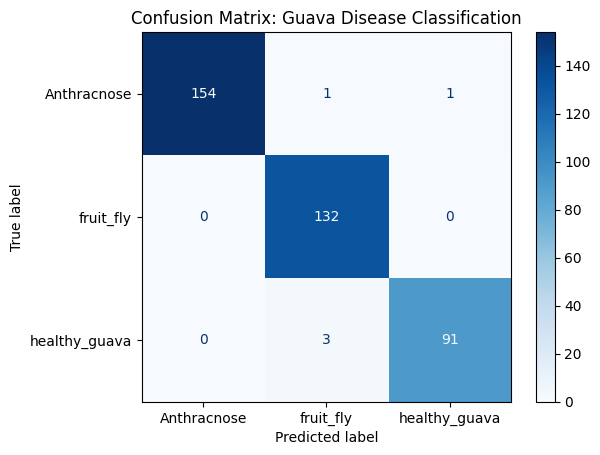

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = test_dataset.classes

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix: Guava Disease Classification')
plt.show()

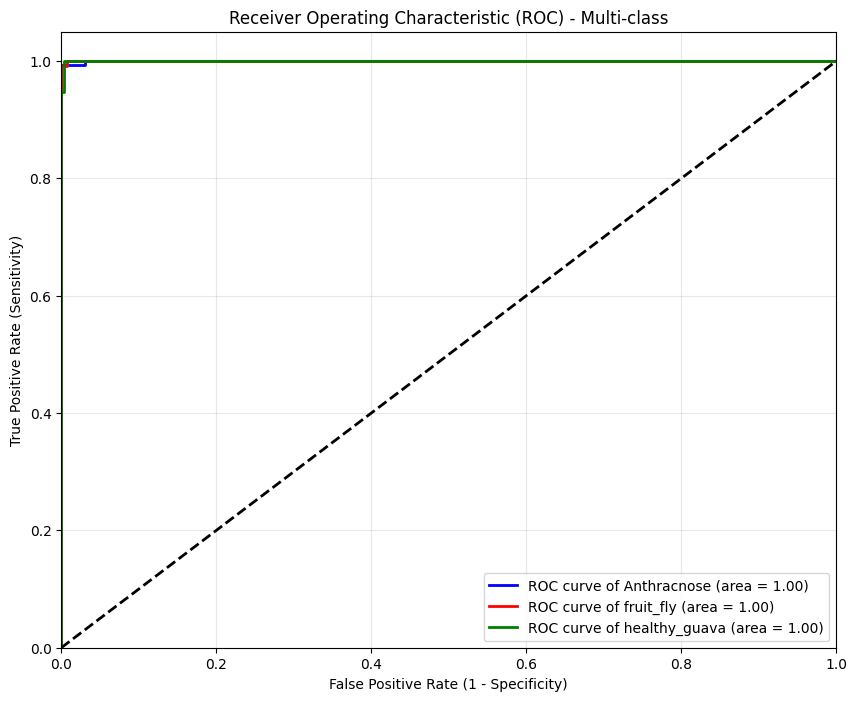

In [11]:
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

n_classes = len(class_names)
all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()